In [23]:
import torch
import torch.nn as nn
torch.manual_seed(42)


NUM_TRAJECTORIES = 10
T = 10
dt = 0.05
CHUNK_STEPS = 5

# Pendulum Params:
BETA = 0.4
OMEGA_0 = 9.81/2
K = 10

total_steps = T//dt

def u_func(t):
    freqs = torch.arange(1, NUM_TRAJECTORIES + 1, dtype=torch.float32).view(-1, 1).to(t.device)
    return torch.sin(freqs * t)

def u_func_val(t):
    if t < T//3:
        return torch.ones((NUM_TRAJECTORIES, 1))*0.3
    else:
        return torch.ones((NUM_TRAJECTORIES, 1))*(-0.9)
    

class PendulumWithSteering(nn.Module):
    def __init__(self, ufunc=u_func):
        super().__init__()
        self.ufunc = ufunc

    def forward(self, t, state):
        theta = state[:, 0:1]
        omega = state[:, 1:2]

        u = self.ufunc(t)

        domega_dt = -2*BETA*omega - OMEGA_0**2 * torch.sin(theta) + K * u
        dtheta_dt = omega

        return torch.cat([dtheta_dt, domega_dt], dim=1)


In [ ]:
from torchdiffeq import odeint
from matplotlib import pyplot as plt

STABILITY_THRESHOLD = 0.1

def is_stable_at_origin(final_state, threshold=STABILITY_THRESHOLD):
    theta, omega = final_state[..., 0], final_state[..., 1]
    return (torch.abs(theta) < threshold) & (torch.abs(omega) < threshold)

# --- Train Stability Loop ---
trajectories = odeint(pendulum_dynamics, y_0s, ts)
stable_mask = is_stable_at_origin(trajectories[-1])

while not stable_mask.all():
    num_unstable = (~stable_mask).sum().item()
    
    # Regenerate steering and y_0s for unstable indices
    new_steering = (torch.rand((NUM_STEERING_JUMP, num_unstable, 1)) * 2 - 1).repeat_interleave(steps_per_jump, dim=0)
    steering_table[:, ~stable_mask, :] = new_steering
    
    new_y_0s = torch.rand((num_unstable, 2))
    new_y_0s[:, 0] = new_y_0s[:, 0] * 2 * torch.pi - torch.pi
    new_y_0s[:, 1] = (new_y_0s[:, 1] - 1/2) * 20
    y_0s[~stable_mask] = new_y_0s
    
    trajectories = odeint(pendulum_dynamics, y_0s, ts)
    stable_mask = is_stable_at_origin(trajectories[-1])

# --- Val Stability Loop ---
trajectories_val = odeint(pendulum_dynamics_val, y_0s_val, ts)
stable_mask_val = is_stable_at_origin(trajectories_val[-1])

while not stable_mask_val.all():
    num_unstable = (~stable_mask_val).sum().item()
    
    new_steering_val = (torch.rand((NUM_STEERING_JUMP, num_unstable, 1)) * 2 - 1).repeat_interleave(steps_per_jump, dim=0)
    steering_table_val[:, ~stable_mask_val, :] = new_steering_val
    
    new_y_0s_val = torch.rand((num_unstable, 2))
    new_y_0s_val[:, 0] = new_y_0s_val[:, 0] * 2 * torch.pi - torch.pi
    new_y_0s_val[:, 1] = (new_y_0s_val[:, 1] - 1/2) * 20
    y_0s_val[~stable_mask_val] = new_y_0s_val
    
    trajectories_val = odeint(pendulum_dynamics_val, y_0s_val, ts)
    stable_mask_val = is_stable_at_origin(trajectories_val[-1])

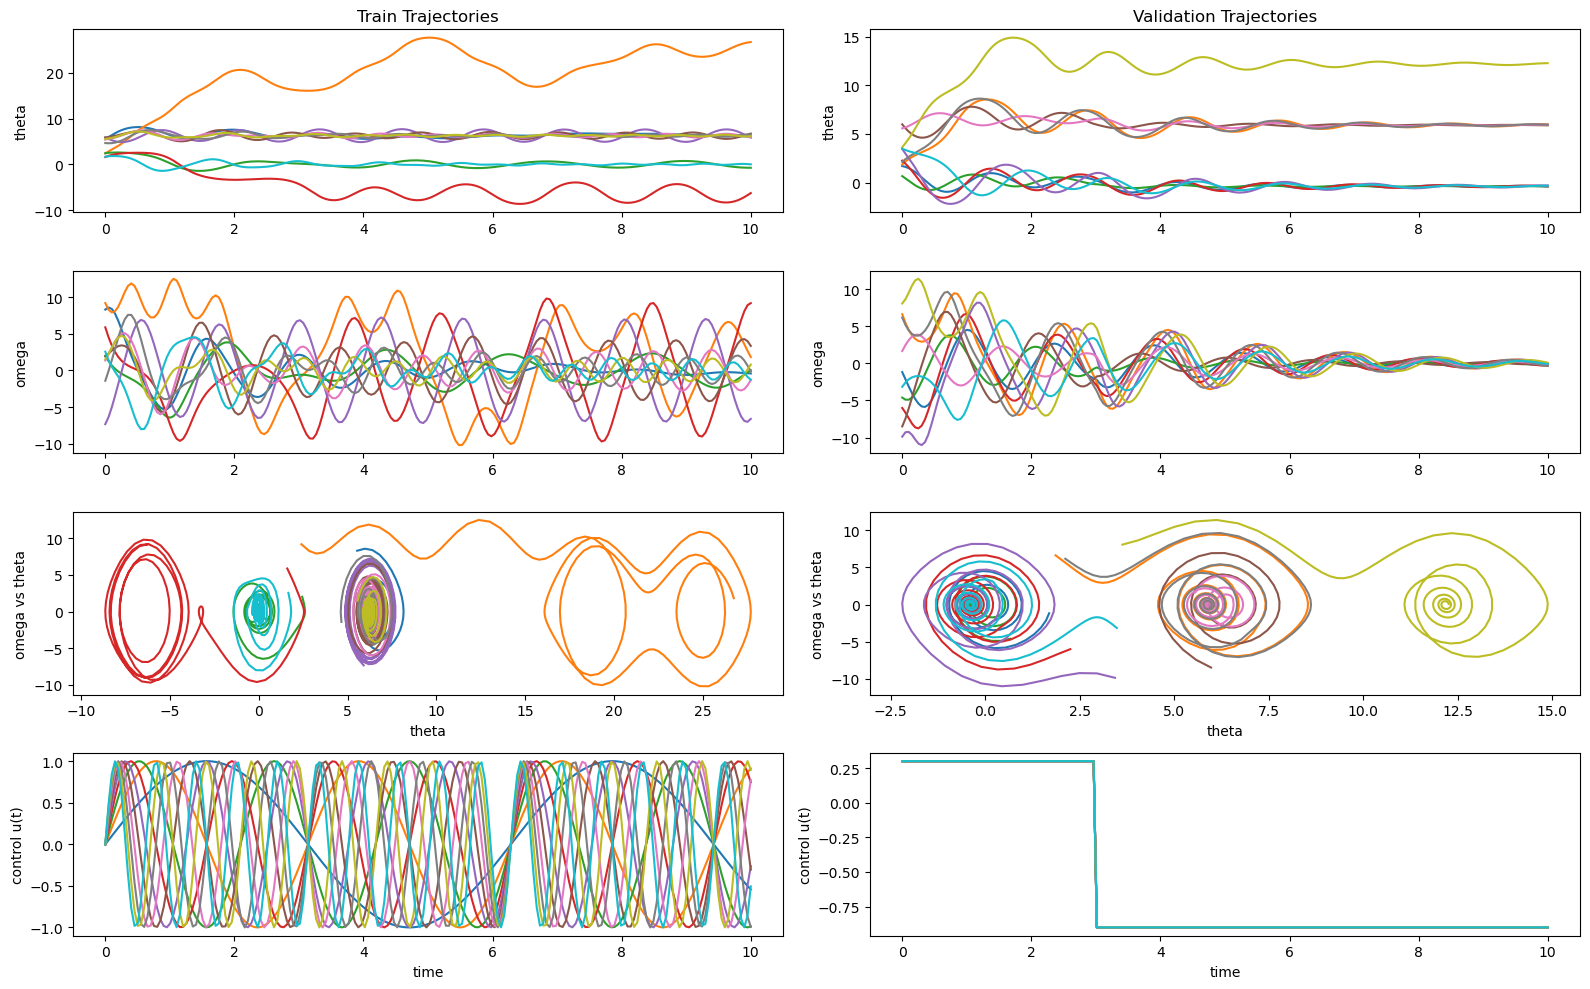

Train shape: torch.Size([200, 10, 2])
Val shape: torch.Size([200, 10, 2])


In [25]:
fig, axs = plt.subplots(4, 2, figsize=(16, 10))

# --- Plot Train Trajectories (Left Column) ---
for i in range(trajectories.shape[1]):
    trajectory = trajectories[:, i, :] 
    thetas, omegas = trajectory[:, 0].tolist(), trajectory[:, 1].tolist()
    
    axs[0, 0].plot(ts, thetas)
    axs[1, 0].plot(ts, omegas)
    axs[2, 0].plot(thetas, omegas)
    u_vals = [u_func(t.view(1))[i, 0].item() for t in ts]
    axs[3, 0].plot(ts, u_vals)

axs[0, 0].set_ylabel("theta")
axs[1, 0].set_ylabel("omega")
axs[2, 0].set_ylabel("omega vs theta")
axs[2, 0].set_xlabel("theta")
axs[3, 0].set_ylabel("control u(t)")
axs[3, 0].set_xlabel("time")
axs[0, 0].set_title("Train Trajectories")

# --- Plot Validation Trajectories (Right Column) ---
for i in range(val_trajectories.shape[1]):
    val_trajectory = val_trajectories[:, i, :] 
    val_thetas, val_omegas = val_trajectory[:, 0].tolist(), val_trajectory[:, 1].tolist()
    
    axs[0, 1].plot(ts, val_thetas)
    axs[1, 1].plot(ts, val_omegas)
    axs[2, 1].plot(val_thetas, val_omegas)
    # Assuming u_func and ts apply to validation in the same way 
    val_u_vals = [u_func_val(t.view(1))[i, 0].item() for t in ts]
    axs[3, 1].plot(ts, val_u_vals)

axs[0, 1].set_ylabel("theta")
axs[1, 1].set_ylabel("omega")
axs[2, 1].set_ylabel("omega vs theta")
axs[2, 1].set_xlabel("theta")
axs[3, 1].set_ylabel("control u(t)")
axs[3, 1].set_xlabel("time")
axs[0, 1].set_title("Validation Trajectories")

plt.tight_layout()
plt.show()

print("Train shape:", trajectories.shape)
print("Val shape:", val_trajectories.shape)

In [26]:
from torchdiffeq import odeint_adjoint

class ODEFunc(nn.Module):
    """Neural network that parameterizes dy/dt = f(y, t)."""

    def __init__(self, u_callable):
        super().__init__()
        self.u_callable = u_callable
        self.net = nn.Sequential(
            nn.Linear(3, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 2)
        )

    def forward(self, t, y):
        u = self.u_callable(t)
        y_and_u = torch.cat([y, u], dim=-1)
        return self.net(y_and_u)

In [27]:
class NeuralODE(nn.Module):
    """Wraps ODEFunc and solves it with torchdiffeq (Tsit5 solver)."""

    def __init__(self, odefun):
        super(NeuralODE, self).__init__()
        self.odefun = odefun
    
    def forward(self, y0, ts):
        res = odeint_adjoint(self.odefun, y0, ts)
        return res

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
print(f"device: {device}")

model = NeuralODE(ODEFunc(u_func)).to(device)

# Data
y_0s = y_0s.to(device)
ts = ts.to(device)
trajectories = trajectories.to(device)

# hyperparameters
num_epochs_adam = 1000
num_epochs_bfgs = 100
print_every = 10
criterion = nn.MSELoss()

num_chunks = int(total_steps//CHUNK_STEPS)

# phase 1: adam
print("--- starting adam phase ---")
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(num_epochs_adam):
    optimizer1.zero_grad()
    epoch_loss = 0.0
    
    for c in range(num_chunks):
        start_idx = c * CHUNK_STEPS
        end_idx = start_idx + CHUNK_STEPS
        
        chunk_ts = ts[start_idx:end_idx] 
        chunk_y0 = trajectories[start_idx] 
        true_chunk = trajectories[start_idx:end_idx] 
        
        pred_chunk = model(chunk_y0, chunk_ts)
        
        loss = criterion(pred_chunk, true_chunk) / num_chunks
        loss.backward()
        
        epoch_loss += loss.item()
        
    optimizer1.step()

    if epoch % print_every == 0:
        with torch.no_grad():
            model.odefun.u_callable = u_func_val
            val_loss = 0.0
            for c in range(num_chunks):
                start_idx = c * CHUNK_STEPS
                end_idx = start_idx + CHUNK_STEPS
                
                chunk_ts = ts[start_idx:end_idx] 
                chunk_y0_val = val_trajectories[start_idx] 
                true_chunk_val = val_trajectories[start_idx:end_idx] 
                
                pred_chunk_val = model(chunk_y0_val, chunk_ts)
                
                val_loss += (criterion(pred_chunk_val, true_chunk_val) / num_chunks).item()
            model.odefun.u_callable = u_func
            
        print(f"Epoch {epoch:4d}, Training Loss: {epoch_loss:.6f}, Validation Loss: {val_loss:.6f}")

# phase 2: l-bfgs
print("\n--- starting l-bfgs phase ---")
optimizer2 = torch.optim.LBFGS(
    model.parameters(), 
    lr=0.01,
    max_iter=20,             
    max_eval=25,             
    tolerance_grad=1e-05,    
    tolerance_change=1e-09,  
    history_size=100,        
    line_search_fn='strong_wolfe'
)

for epoch in range(num_epochs_bfgs):
    def closure():
        optimizer2.zero_grad()
        total_closure_loss = 0.0
        
        for c in range(num_chunks):
            start_idx = c * CHUNK_STEPS
            end_idx = start_idx + CHUNK_STEPS
            
            chunk_ts = ts[start_idx:end_idx] 
            chunk_y0 = trajectories[start_idx] 
            true_chunk = trajectories[start_idx:end_idx] 
            
            pred_chunk = model(chunk_y0, chunk_ts)
            
            loss = criterion(pred_chunk, true_chunk) / num_chunks
            loss.backward()
            
            total_closure_loss += loss
            
        return total_closure_loss

    # optimizer.step() naturally returns the final loss evaluated during the closure
    final_loss = optimizer2.step(closure)

    if epoch % print_every == 0:
        with torch.no_grad():
            model.odefun.u_callable = u_func_val
            val_loss = 0.0
            for c in range(num_chunks):
                start_idx = c * CHUNK_STEPS
                end_idx = start_idx + CHUNK_STEPS
                
                chunk_ts = ts[start_idx:end_idx] 
                chunk_y0_val = val_trajectories[start_idx] 
                true_chunk_val = val_trajectories[start_idx:end_idx] 
                
                pred_chunk_val = model(chunk_y0_val, chunk_ts)
                
                val_loss += (criterion(pred_chunk_val, true_chunk_val) / num_chunks).item()
            model.odefun.u_callable = u_func
            
        print(f"Epoch {epoch:4d}, Training Loss: {epoch_loss:.6f}, Validation Loss: {val_loss:.6f}")
        

device: cpu
--- starting adam phase ---
Epoch    0, Training Loss: 1.890231, Validation Loss: 0.782793
Epoch   10, Training Loss: 1.526521, Validation Loss: 0.679915
Epoch   20, Training Loss: 1.260380, Validation Loss: 0.840919
Epoch   30, Training Loss: 0.975428, Validation Loss: 1.439202
Epoch   40, Training Loss: 0.905532, Validation Loss: 1.601856
Epoch   50, Training Loss: 0.835963, Validation Loss: 1.336436
Epoch   60, Training Loss: 0.777634, Validation Loss: 1.243490
Epoch   70, Training Loss: 0.727546, Validation Loss: 1.202430
Epoch   80, Training Loss: 0.676892, Validation Loss: 1.160293
Epoch   90, Training Loss: 0.621444, Validation Loss: 1.109759
Epoch  100, Training Loss: 0.558405, Validation Loss: 1.044951
Epoch  110, Training Loss: 0.500327, Validation Loss: 0.993455
Epoch  120, Training Loss: 0.445025, Validation Loss: 0.960430
Epoch  130, Training Loss: 0.389844, Validation Loss: 0.848374
Epoch  140, Training Loss: 0.339355, Validation Loss: 0.802356
Epoch  150, Tra

KeyboardInterrupt: 

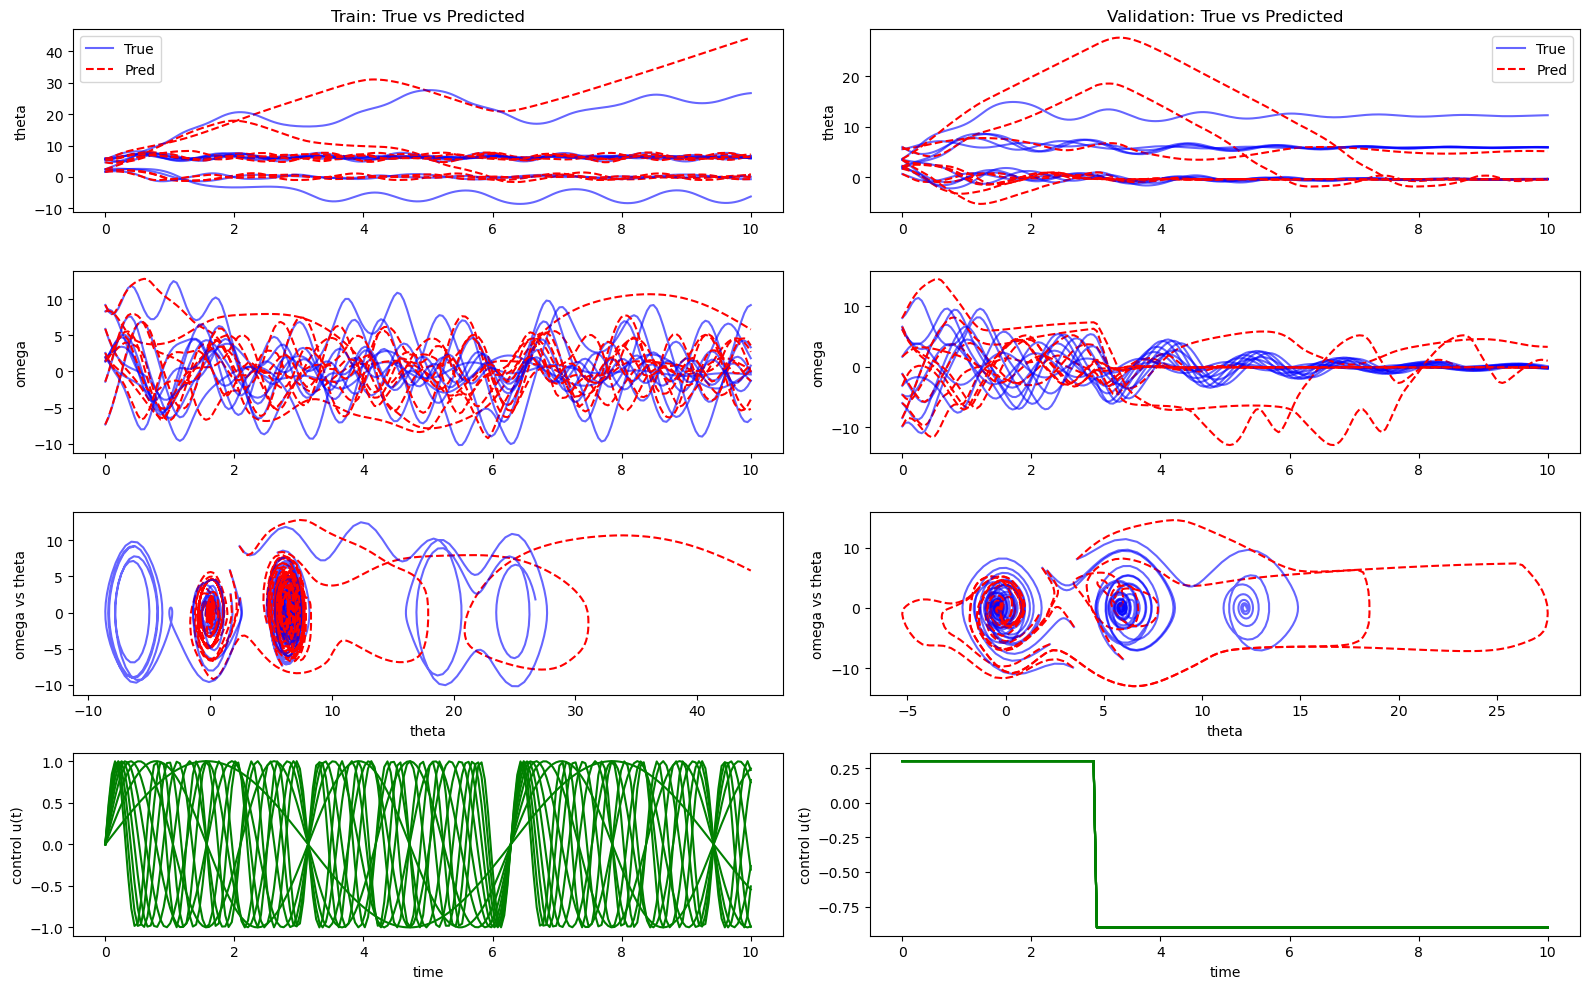

In [29]:
# --- Evaluation and Plotting ---
with torch.no_grad():
    # 1. Predict on Train (using standard u_func)
    model.odefun.u_callable = u_func 
    pred_trajectories = model(y_0s, ts)
    
    # 2. Predict on Validation (must swap to u_func_val to get the right physics!)
    model.odefun.u_callable = u_func_val 
    pred_val_trajectories = model(y_0s_val, ts)
    
    # Swap back to train control just in case
    model.odefun.u_callable = u_func

# Convert time tensor to numpy for plotting
ts_np = ts.cpu().numpy()

fig, axs = plt.subplots(4, 2, figsize=(16, 10))

# --- Plot Train Trajectories (Left Column) ---
for i in range(trajectories.shape[1]):
    # Truth
    thetas = trajectories[:, i, 0].cpu().numpy()
    omegas = trajectories[:, i, 1].cpu().numpy()
    
    # Predictions
    p_thetas = pred_trajectories[:, i, 0].cpu().numpy()
    p_omegas = pred_trajectories[:, i, 1].cpu().numpy()
    
    # Plot Theta
    axs[0, 0].plot(ts_np, thetas, color='blue', alpha=0.6, label='True' if i==0 else "")
    axs[0, 0].plot(ts_np, p_thetas, color='red', linestyle='--', label='Pred' if i==0 else "")
    
    # Plot Omega
    axs[1, 0].plot(ts_np, omegas, color='blue', alpha=0.6)
    axs[1, 0].plot(ts_np, p_omegas, color='red', linestyle='--')
    
    # Plot Phase
    axs[2, 0].plot(thetas, omegas, color='blue', alpha=0.6)
    axs[2, 0].plot(p_thetas, p_omegas, color='red', linestyle='--')
    
    # Plot Control
    u_vals = [u_func(t.view(1))[i, 0].item() for t in ts]
    axs[3, 0].plot(ts_np, u_vals, color='green')

axs[0, 0].set_ylabel("theta")
axs[1, 0].set_ylabel("omega")
axs[2, 0].set_ylabel("omega vs theta")
axs[2, 0].set_xlabel("theta")
axs[3, 0].set_ylabel("control u(t)")
axs[3, 0].set_xlabel("time")
axs[0, 0].set_title("Train: True vs Predicted")
axs[0, 0].legend()

# --- Plot Validation Trajectories (Right Column) ---
for i in range(val_trajectories.shape[1]):
    # Truth
    val_thetas = val_trajectories[:, i, 0].cpu().numpy()
    val_omegas = val_trajectories[:, i, 1].cpu().numpy()
    
    # Predictions
    p_val_thetas = pred_val_trajectories[:, i, 0].cpu().numpy()
    p_val_omegas = pred_val_trajectories[:, i, 1].cpu().numpy()
    
    # Plot Theta
    axs[0, 1].plot(ts_np, val_thetas, color='blue', alpha=0.6, label='True' if i==0 else "")
    axs[0, 1].plot(ts_np, p_val_thetas, color='red', linestyle='--', label='Pred' if i==0 else "")
    
    # Plot Omega
    axs[1, 1].plot(ts_np, val_omegas, color='blue', alpha=0.6)
    axs[1, 1].plot(ts_np, p_val_omegas, color='red', linestyle='--')
    
    # Plot Phase
    axs[2, 1].plot(val_thetas, val_omegas, color='blue', alpha=0.6)
    axs[2, 1].plot(p_val_thetas, p_val_omegas, color='red', linestyle='--')
    
    # Plot Control
    val_u_vals = [u_func_val(t.view(1))[i, 0].item() for t in ts]
    axs[3, 1].plot(ts_np, val_u_vals, color='green')

axs[0, 1].set_ylabel("theta")
axs[1, 1].set_ylabel("omega")
axs[2, 1].set_ylabel("omega vs theta")
axs[2, 1].set_xlabel("theta")
axs[3, 1].set_ylabel("control u(t)")
axs[3, 1].set_xlabel("time")
axs[0, 1].set_title("Validation: True vs Predicted")
axs[0, 1].legend()

plt.tight_layout()
plt.show()